# PyTorch

**PyTorch** - jeden z najczęściej używanych frameworków do uczenia głębokiego.


Zaimportujmy naszą bibliotekę używając słówka **import**:

In [ ]:
import torch
print("Wersja PyTorch:", torch.__version__)

Wersja PyTorch: 2.8.0+cu126


## Tensory

Tensory to podstawowe obiekty w PyTorch – bardzo podobne do tablic w NumPy, ale mogą działać na GPU i obsługują automatyczne różniczkowanie (to się przyda później!)


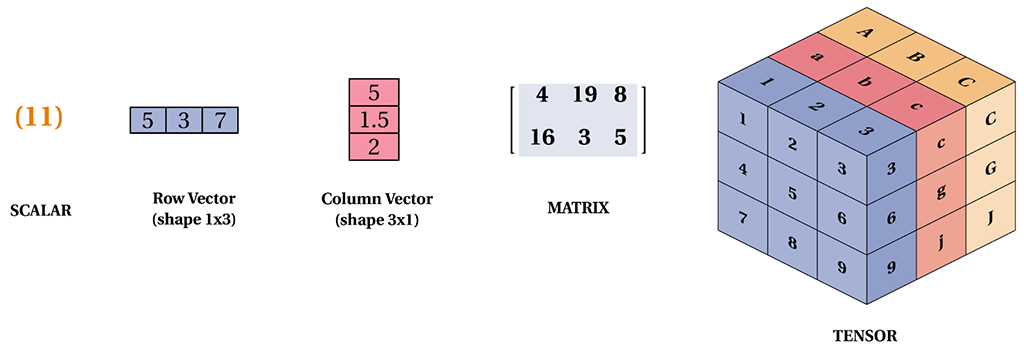

In [ ]:
# Tensor na podstawie listy
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print("Tensor z listy:\n", x)

# Tensor losowy
y = torch.rand((2, 2))
print("Tensor losowy:\n", y)

# Operacje na tensorach
print("Dodawanie:\n", x + y)
print("Mnożenie macierzowe:\n", x @ y)


Tensor z listy:
 tensor([[1., 2.],
        [3., 4.]])
Tensor losowy:
 tensor([[0.8449, 0.0545],
        [0.4702, 0.6939]])
Dodawanie:
 tensor([[1.8449, 2.0545],
        [3.4702, 4.6939]])
Mnożenie macierzowe:
 tensor([[1.7853, 1.4424],
        [4.4156, 2.9393]])


W deep learningu operacje te mają kluczowe znaczenie:
* **Dodawanie tensorów** – używane do sumowania wag, biasów lub wyników warstw (np. w skip connection).
* **Mnożenie macierzowe** – główna operacja w każdej warstwie sieci (np. y = Wx + b), odpowiada za propagację informacji i obliczanie aktywacji.

Kolejne przykłady pokazują praktyczne użycie tensorów wyższych wymiarów w deep learningu:

In [ ]:
# Tensor 3D (batch dwoch macierzy 2x2)
z = torch.rand((2, 2, 2))
print("\nTensor 3D:", z.shape)
print(z)

# Dodawanie element po elemencie
print("\nDodawanie 3D (x + z[0]):\n", x + z[0])

# Mnożenie macierzowe dla batcha
# (batch matrix multiplication)
result = torch.matmul(z, x)
print("\nMnożenie (z @ x):\n", result)

# Tensor 4D (np. mini-batch obrazów: batch_size=2, kanały=3, wys=4, szer=4)
images = torch.rand((2, 3, 4, 4))
print("\nTensor 4D images (kształt):", images.shape)


Tensor 3D: torch.Size([2, 2, 2])
tensor([[[0.9237, 0.3823],
         [0.2621, 0.9409]],

        [[0.0678, 0.2308],
         [0.2414, 0.0185]]])

Dodawanie 3D (x + z[0]):
 tensor([[1.9237, 2.3823],
        [3.2621, 4.9409]])

Mnożenie (z @ x):
 tensor([[[2.0707, 3.3767],
         [3.0849, 4.2880]],

        [[0.7603, 1.0590],
         [0.2970, 0.5569]]])

Tensor 4D images (kształt): torch.Size([2, 3, 4, 4])


* **Batching** – operacje na wielu danych jednocześnie (np. kilka obrazów, wiele macierzy) zwiększają efektywność uczenia.


* **Dodawanie element-po-elemencie** – pokazuje manipulację pojedynczymi warstwami lub biasami. Biasy warstw – podczas forward pass do każdej warstwy dodaje się bias (np. y = Wx + b). Dodawanie element-po-elemencie w tensorach odpowiada właśnie tej operacji.


* **Mnożenie macierzy dla batcha** – podstawowa operacja propagacji w sieciach neuronowych, obsługuje wiele próbek naraz.


* **Tensor 4D** – reprezentuje np. mini-batch obrazów w CNN, pokazuje jak dane wejściowe mają kształt (batch, channels, height, width). Channels określa, ile warstw informacji zawiera każdy obraz w batchu (np. RGB=3, GrayScale=1).


Operacje na macierzach: https://pytorch.org/blog/inside-the-matrix/

Przydane atrybuty tensorów:

In [ ]:
# wymiary
tensor = torch.rand(3,4)
tensor.shape

torch.Size([3, 4])

In [ ]:
# typ wartości
tensor.dtype

torch.float32

In [ ]:
# gdze jest przechowywany
tensor.device

device(type='cpu')

## Autograd (automatyczne różniczkowanie)

PyTorch pozwala łatwo obliczać pochodne, co jest ważne przy trenowaniu sieci neuronowych.


In [ ]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = a * b + b**2

print("c =", c.item())

c.backward()  # obliczamy pochodne
print("dc/da =", a.grad.item())
print("dc/db =", b.grad.item())


c = 15.0
dc/da = 3.0
dc/db = 8.0


Po co liczymy pochodne?

Ucząć sieć neuronową będziemy dostosowywać wagi tak, żeby funkcja straty (loss function) była jak najmniejsza.

Funkcja straty = jak bardzo model się myli (chcemy żeby się mylił jak najmniej! 😀)

Wagi chcemy zmienić w dobrą stronę, dlatego potrzebujemy wiedzieć:
w którą stronę i o ile przesunąć wagi.

Tadam! Właśnie to nam mówią pochodne!

Przypomnienie pochodnych:

Mamy:
```
a=2.0
b=3.0
c = a * b + b**2
```

Licząc ręcznie:

Pochodna po a
```
Część pierwsza: a⋅b → traktujemy b jako stałą → pochodna względem a to b.
Część druga: b^2 → nie ma a, więc pochodna to 0.
dc/da = b + 0 = b
```

Pochodna po b
```
Część pierwsza: a⋅b → a jest stałe, a b zmienne → pochodna to a.
Część druga: b^2 → pochodna to 2b.
dc/db = a + 2b
```




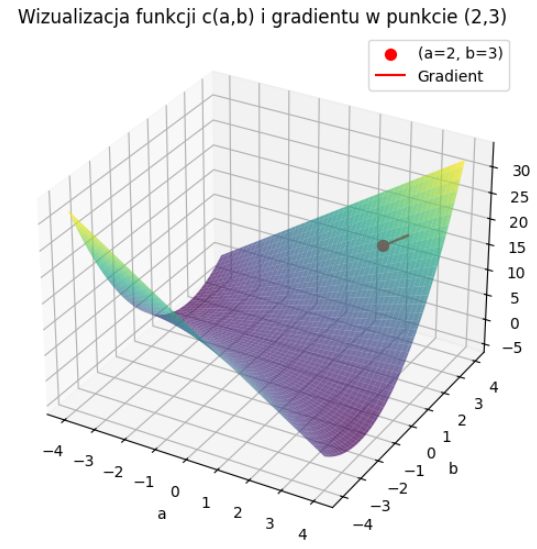

Pochodna funkcji f(x) w punkcie x0 opisuje **jak bardzo funkcja zmienia swoją wartość, gdy zmieniamy zmienną niezależną** o ilość na tyle małą, żeby móc uchwycić natychmiastową szybkość zmiany funkcji.

W deep learningu **gradient** = **szybkość zmiany funkcji straty względem wagi** → mówi, w którą stronę i o ile zmienić wagę, żeby zmniejszyć błąd.

## Przygotujmy prosty model (regresja liniowa)

Tutaj mamy losowe dane. Wizualizujac je możemy łatwo stwierdzić, że będziemy mieli do czynienia z regresja liniową.

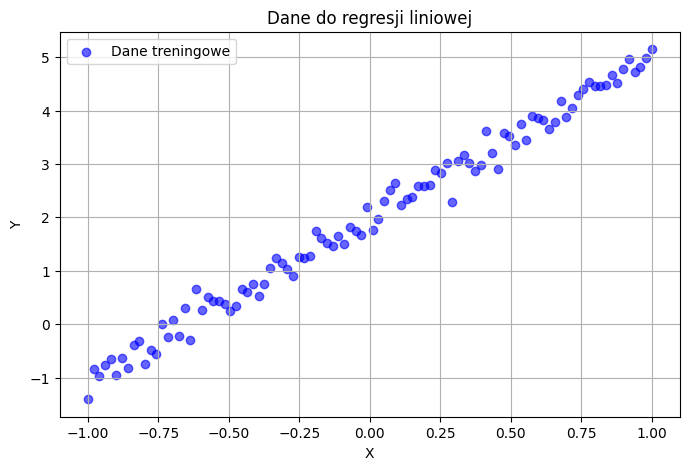

In [ ]:
import matplotlib.pyplot as plt

# Dane treningowe
X = torch.linspace(-1, 1, 100).unsqueeze(1)
Y = 3 * X + 2 + 0.2 * torch.randn(X.size())

# Wizualzacja
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), color='blue', alpha=0.6, label='Dane treningowe')
plt.title('Dane do regresji liniowej')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

Teraz potrzebujemy stworzyć nasz model

In [ ]:
import torch.nn as nn

model = nn.Linear(1, 1)  # jedno wejście, jedno wyjście
print(model.weight, model.bias)

Parameter containing:
tensor([[-0.3671]], requires_grad=True) Parameter containing:
tensor([0.0067], requires_grad=True)


Mamy jedno wejście (x) oraz jedno wyjście (y):
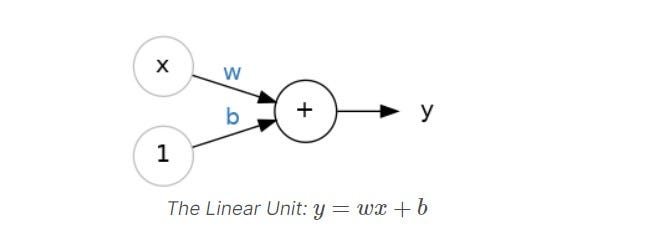

Trenować będziemy wagi (w) oraz bias (b). Nasz print pokazał nam obecne wartości z któymi został stworzony model - losowa wartość wagi i biasu, oba z włączonym autograd.

Po zdefiniowaniu modelu musimy powiedzieć PyTorchowi jak ocenić, czy model dobrze się uczy i jak ma aktualizować swoje parametry (wagi i biasy).  
Służą do tego dwa elementy:
*  Funkcja straty - jak bardzo przewidywania modelu różnią się od rzeczywistych wartości
*  Optymalizator - aktualizuje parametry modelu na podstawie gradientów policzonych przez autograd

In [ ]:
criterion = nn.MSELoss()              # średni błąd kwadratowy
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

Mean Squared Error Loss - średni błąd kwdratowy

Stochastic Gradient Descent – najprostszy algorytm optymalizacji.

O innych funkcjach starty i optymalizatorach nauczymy się na innych zajęciach.

Teraz jak wszystko przygotowaliśmy, musimy wszystko zebrać w całość:

In [ ]:
epochs = 100
for epoch in range(epochs):
    y_pred = model(X) # 1.
    loss = criterion(y_pred, Y) # 2.

    optimizer.zero_grad()
    loss.backward() # 3.
    optimizer.step() # 4.

    # printujmy sobie co 20 epok jak wygląda nasz loss
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 20, Loss: 0.3893
Epoch 40, Loss: 0.0569
Epoch 60, Loss: 0.0372
Epoch 80, Loss: 0.0360
Epoch 100, Loss: 0.0359


W każdej epoce treningu dzieje się następujący proces:
1.  **Forward pass**: Model generuje przewidywania y_pred = model(X)
2.  **Loss**: Liczymy stratę: loss = criterion(y_pred, Y)
3.  **Backward pass**: PyTorch automatycznie oblicza pochodne (loss.backward())
4.  **Update**: Optymalizator aktualizuje parametry modelu: optimizer.step()

W PyTorch optimizer.zero_grad() zeruje wszystkie gradienty przechowywane w tensorach z requires_grad=True.
Każde wywołanie backward() dodaje gradienty do już istniejących w .grad.
Dlatego przed kolejnym krokiem optymalizacji trzeba wyczyścić poprzednie gradienty, żeby nie sumowały się z nowymi.

Cały proces powtarzamy wiele razy, aż loss przestanie się zmniejszać lub dojdziemy do maxymalnej ilości epok (warto poeksperymentować).

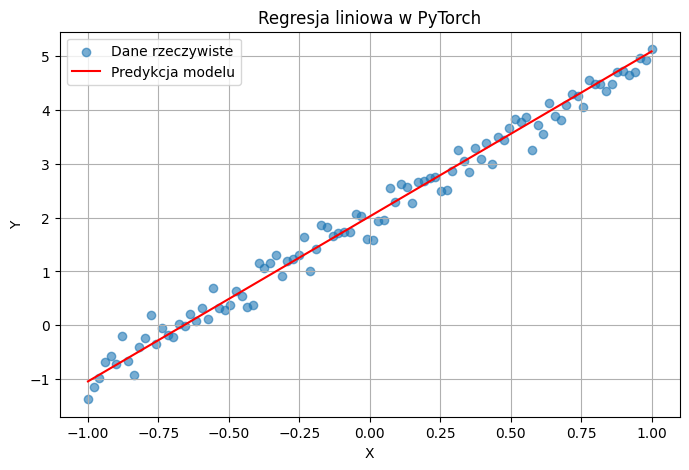

In [ ]:
import matplotlib.pyplot as plt

predicted = model(X).detach()  # odłączamy od grafu autograd
# Wynikowy tensor nie będzie śledził gradientów, niezależnie od tego, co zrobimy później
# Detachujemy model jak już przestajemy go uczyć

# Wizualzacja
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), label='Dane rzeczywiste', alpha=0.6)
plt.plot(X.numpy(), predicted.numpy(), color='red', label='Predykcja modelu')
plt.title('Regresja liniowa w PyTorch')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


Model nn.Linear(1, 1) przewiduje wartość Y dla danego X, zakładając, że zależność jest liniowa.

Dla każdego punktu, MSE mierzy kwadrat różnicy między przewidywaną, a prawdziwą wartością.

* Kwadrat powoduje, że większe błędy są karane silniej.
* Średnia po wszystkich punktach daje jedną liczbę – globalną miarę błędu modelu.

Model próbuje dopasować prostą, która najlepiej aproksymuje dane (X, Y) w sensie minimalnego średniego błędu kwadratowego (MSE).
* w – waga modelu (nachylenie prostej).
* b – bias (przesunięcie prostej).

Można powiedzięc, że po epokach treningu model „nauczył się” najlepszej prostej, która minimalizuje MSE, czyli w praktyce „podziału” punktów według linii najlepszego dopasowania.



# Zadania

## Zadanie 1

1. Utwórz tensor A o wymiarach (3, 4) wypełniony liczbami losowymi z rozkładu normalnego.

2. Oblicz:
    1. średnią wartość wszystkich elementów,
    2. sumę wzdłuż kolumn,
    3. transpozycję tensora.

Pamiętaj aby wydrukować wszystkie wyniki.

In [ ]:
import torch

# 1. Tworzenie tensora
A_tensor = torch.rand((3,4))
print(f'Tensor A: \n {A_tensor}\n')

# 2.1. Średnia wszystkich elementów
print(f'Średnia wszystkich elementów: \n { torch.mean(A_tensor) }\n')

# 2.2. Suma wzdłuż kolumn
print(f'Suma wzdłuż kolum: \n { torch.sum(A_tensor, dim=0) }\n')


# 2.3. Transpozycja
print(f'Suma wzdłuż kolum: \n { torch.transpose(A_tensor, 0, 1) }\n')

Tensor A: 
 tensor([[0.7698, 0.0608, 0.4974, 0.2803],
        [0.8601, 0.7866, 0.2456, 0.8906],
        [0.8289, 0.5099, 0.7433, 0.4991]])

Średnia wszystkich elementów: 
 0.5810235142707825

Suma wzdłuż kolum: 
 tensor([2.4587, 1.3573, 1.4862, 1.6700])

Suma wzdłuż kolum: 
 tensor([[0.7698, 0.8601, 0.8289],
        [0.0608, 0.7866, 0.5099],
        [0.4974, 0.2456, 0.7433],
        [0.2803, 0.8906, 0.4991]])



## Zadanie 2
1. Utwórz tensor z jedną wartością: 5.0.
2. Zdefiniuj funkcję `y = x**2 + 3*x + 1`.
3. Oblicz pochodną dy/dx za pomocą .backward() i wydrukuj gradient.

In [ ]:
import torch
# 1.
x = torch.tensor(5.0, requires_grad=True)

# 2. Funkcja
y = x**2 + 3*x + 1

# 3. Obliczenie gradientu
y.backward()
print(f'Gradient dy/dx: {x.grad.item()}')

Gradient dy/dx: 13.0


## Zadanie 3

Na podstawie poniższego zestawu danych:
1. Stwórz prosty model liniowy nn.Linear(1,1).
2. Użyj MSELoss i optymalizatora SGD.
3. Wytrenuj model i zapisz wynik dla 20 epok, 50 epok i 100 epok.
4. Narysuj dane i predykcję modelu.

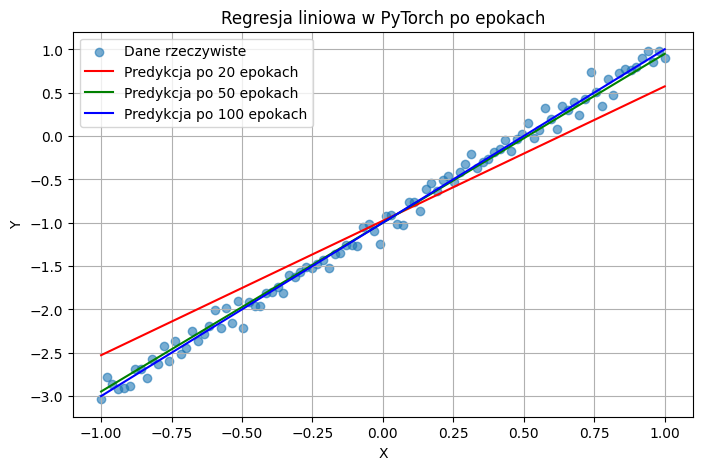

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Dane
X = torch.linspace(-1, 1, 100).unsqueeze(1)
Y = 2*X - 1 + 0.1*torch.randn(X.size())

#TODO
model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
epochs = 100

plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), label='Dane rzeczywiste', alpha=0.6)

for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) == 20:
        plt.plot(X.numpy(), model(X).detach().numpy(), color='red', label='Predykcja po 20 epokach')
    if (epoch+1) == 50:
      plt.plot(X.numpy(), model(X).detach().numpy(), color='green', label='Predykcja po 50 epokach')
    if (epoch+1) == 100:
      plt.plot(X.numpy(), model(X).detach().numpy(), color='blue', label='Predykcja po 100 epokach')

plt.title('Regresja liniowa w PyTorch po epokach')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()